# Assignment: Building a Tiny Transformer That Learns Addition

## Overview

In this assignment you will implement a minimal GPT-style Transformer inspired by:

- The Tiny Transformer walkthrough notebook
- Andrej Karpathy's nanoGPT / miniGPT style training loops
- The `projects/adder` sequence modeling idea

Your model will learn to solve integer addition problems such as:

```text
12+35=47
```

and later generalize to unseen:

```text
384+217=601
```

The assignment is intentionally structured in milestones so that you build the system incrementally and debug each layer independently.

# Learning Goals

By the end of this assignment you should be able to:

1. Build a tokenizer and character vocabulary
2. Generate autoregressive training data
3. Implement causal self-attention from scratch
4. Assemble a Transformer block
5. Train a tiny GPT-like language model
6. Generate predictions autoregressively
7. Evaluate model quality using real mathematical checks

# Problem Setup

We will train a character-level Transformer.

Input examples:

```text
12+7=19
```

```text
384+217=601
```

The model learns one next-character prediction at a time.

Example training sequence:

```text
1 2 + 7 = 1 9
```

Targets are shifted by one token:

```text
2 + 7 = 1 9 <END>
```

This is exactly the same autoregressive training strategy used by GPT models.

# Starter Imports


In [1]:
import torch
import torch.nn as nn
from torch.nn import functional as F
import random
import math

# Reproducibility
random.seed(42)
torch.manual_seed(42)

# Device
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cpu


# Milestone 1 — Tokenizer & Dataset

## Goal

Build:

- vocabulary
- tokenizer
- dataset generator
- batching logic

## Step 1 — Generate Addition Problems
Complete the function.

In [2]:
import random

# Generate random addition problems
# Example:
# 12+35=47\n
def generate_example(max_digits=2):
    # 1. Sample two random integers
    max_val = 10**max_digits - 1
    a = random.randint(0, max_val)
    b = random.randint(0, max_val)

    # 2. Compute the answer
    c = a + b

    # 3. Return formatted string
    return f"{a}+{b}={c}\n"

## Step 2 — Build a Dataset String

Generate many training examples.

In [3]:
# Create a long training string containing many examples

train_text = ""

for _ in range(50000):
    train_text += generate_example()

print(train_text[:200])

81+14=95
3+94=97
35+31=66
28+17=45
94+13=107
86+94=180
69+11=80
75+54=129
4+3=7
11+27=38
29+64=93
77+3=80
71+25=96
91+83=174
89+69=158
53+28=81
57+75=132
35+0=35
97+20=117
89+54=143
43+35=78
19+27=46



## Step 3 — Build Vocabulary

Extract all unique characters.

Typical vocabulary:
```python
['\n', '+', '0', '1', '2', ..., '9', '=']
```

Complete the tokenizer.

In [4]:
# 1. Find unique chars
chars = sorted(list(set(train_text)))
vocab_size = len(chars)

# 2. Build stoi dictionary
stoi = {ch: i for i, ch in enumerate(chars)}
# 3. Build itos dictionary
itos = {i: ch for i, ch in enumerate(chars)}


def encode(s):
    """Encodes a string into a list of integers."""
    return [stoi[ch] for ch in s]


def decode(tokens):
    """Decodes a list of integers into a string."""
    return "".join([itos[ix] for ix in tokens])

print(f"Vocabulary: {chars}")
print(f"Vocabulary size: {vocab_size}")

Vocabulary: ['\n', '+', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '=']
Vocabulary size: 13


## Step 4 — Convert Dataset to Tokens

In [5]:
# Convert the text dataset into integer tokens

data = torch.tensor(encode(train_text), dtype=torch.long)

print(data[:20])

tensor([10,  3,  1,  3,  6, 12, 11,  7,  0,  5,  1, 11,  6, 12, 11,  9,  0,  5,
         7,  1])


## Step 5 — Create Batch Loader

The model learns next-token prediction.

Targets are shifted by one character.

In [6]:
batch_size = 64
block_size = 32

def get_batch(split='train'):
    # For now, we only have a 'train' split based on the generated data
    # In a real scenario, you'd split your `data` into training and validation sets.
    # We are using the full `data` for simplicity here.

    # 1. Sample random starting indices
    ix = torch.randint(len(data) - block_size, (batch_size,))

    # 2. Create X sequences
    X = torch.stack([data[i:i+block_size] for i in ix])

    # 3. Create Y shifted sequences
    Y = torch.stack([data[i+1:i+block_size+1] for i in ix])

    return X.to(device), Y.to(device)

## Verification Cell

Run this before moving on.


In [7]:
X, Y = get_batch()

print("X shape:", X.shape)
print("Y shape:", Y.shape)

print("Decoded sample:")
print(decode(X[0].tolist()))

print("Target sample:")
print(decode(Y[0].tolist()))

X shape: torch.Size([64, 32])
Y shape: torch.Size([64, 32])
Decoded sample:
57+39=96
64+42=106
51+23=74
27+5
Target sample:
7+39=96
64+42=106
51+23=74
27+57


Expected behavior:

- `Y` is `X` shifted by one character
- decoded text looks like valid addition expressions

# Milestone 2 — Causal Multi-Head Attention

## Goal

Implement masked self-attention.

This is the core idea behind GPT.

Each token:

- looks at previous tokens
- cannot see future tokens

# Step 1 — Single Attention Head

Complete the module.

In [8]:
class Head(nn.Module):

    def __init__(self, input_dim, head_size):
        super().__init__()

        # Key, query, and value projections
        self.key = nn.Linear(input_dim, head_size, bias=False)
        self.query = nn.Linear(input_dim, head_size, bias=False)
        self.value = nn.Linear(input_dim, head_size, bias=False)

        # Register causal mask buffer
        self.register_buffer(
            'tril',
            torch.tril(torch.ones(block_size, block_size))
        )

    def forward(self, x):

        B, T, C = x.shape

        # Compute keys, queries, values
        k = self.key(x)   # (B, T, head_size)
        q = self.query(x) # (B, T, head_size)
        v = self.value(x) # (B, T, head_size)

        # Attention scores ( "affinities" )
        # (B, T, head_size) @ (B, head_size, T) -> (B, T, T)
        weights = q @ k.transpose(-2, -1)

        # Scale attention scores
        weights = weights * (C ** -0.5)

        # IMPORTANT:
        # Apply causal mask
        weights = weights.masked_fill(
            self.tril[:T, :T] == 0,
            float('-inf')
        )

        # Softmax
        weights = F.softmax(weights, dim=-1)

        # Return weighted aggregation of values
        out = weights @ v # (B, T, T) @ (B, T, head_size) -> (B, T, head_size)

        return out

## Step 2 — Multi-Head Attention

In [9]:
class MultiHeadAttention(nn.Module):

    def __init__(self, n_embd, num_heads, head_size, dropout):
        super().__init__()

        # Create multiple attention heads
        self.heads = nn.ModuleList([Head(n_embd, head_size) for _ in range(num_heads)])
        # Linear layer to project the concatenated outputs
        self.proj = nn.Linear(num_heads * head_size, n_embd)
        self.attn_dropout = nn.Dropout(dropout)

    def forward(self, x):

        # Concatenate outputs from each head
        out = torch.cat([h(x) for h in self.heads], dim=-1)
        # Project the concatenated output back to n_embd dimensions
        out = self.attn_dropout(self.proj(out))

        return out

## Verification Cell

In [10]:
x = torch.randn(4, block_size, 64) # Note: n_embd is 64 based on suggested hyperparameters

# Assuming n_embd is globally available or passed to Head
n_embd = 64 # Temporary, as n_embd will be defined in TinyGPT

head = Head(n_embd, 16)
out = head(x)

print(out.shape)

torch.Size([4, 32, 16])


Expected output:
```python
torch.Size([4, block_size, 16])
```

# Milestone 3 — Transformer Block & Training Loop

## Goal

Build:

- Feed-forward network
- Layer normalization
- Residual connections
- Full Transformer block
- GPT model
- Training loop

# Step 1 — Feed Forward Network


In [11]:
class FeedForward(nn.Module):

    def __init__(self, n_embd, dropout):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),
            nn.ReLU(),
            nn.Linear(4 * n_embd, n_embd),
            nn.Dropout(dropout) # Using the passed dropout rate
        )

    def forward(self, x):

        return self.net(x)

# Step 2 — Transformer Block

Use:

- attention
- feed forward
- layer norm
- residual connections

In [12]:
class Block(nn.Module):

    def __init__(self, n_embd, n_head, dropout):
        super().__init__()

        head_size = n_embd // n_head

        # Multi-Head Attention
        self.sa = MultiHeadAttention(n_embd, n_head, head_size, dropout)
        # Feed Forward Network
        self.ffwd = FeedForward(n_embd, dropout)
        # Layer Normalization
        self.ln1 = nn.LayerNorm(n_embd)
        self.ln2 = nn.LayerNorm(n_embd)
        self.dropout_sa = nn.Dropout(dropout)
        self.dropout_ffwd = nn.Dropout(dropout)

    def forward(self, x):

        # Residual connections and Layer Normalization with dropout
        x = x + self.dropout_sa(self.sa(self.ln1(x)))
        x = x + self.dropout_ffwd(self.ffwd(self.ln2(x)))

        return x

# Step 3 — Complete GPT Model

In [13]:
class TinyGPT(nn.Module):

    def __init__(self, n_embd, n_head, n_layer, dropout=0.1):
        super().__init__()

        # Hyperparameters
        global vocab_size # Get vocab_size from the global context

        self.token_embedding_table = nn.Embedding(vocab_size, n_embd)
        self.position_embedding_table = nn.Embedding(block_size, n_embd)
        self.dropout_emb = nn.Dropout(dropout)
        self.blocks = nn.Sequential(*[Block(n_embd, n_head=n_head, dropout=dropout) for _ in range(n_layer)])
        self.ln_f = nn.LayerNorm(n_embd) # Final layer norm
        self.lm_head = nn.Linear(n_embd, vocab_size)

    def forward(self, idx, targets=None):

        B, T = idx.shape

        # idx and targets are both (B,T) tensor of integers
        tok_emb = self.token_embedding_table(idx) # (B,T,C)
        pos_emb = self.position_embedding_table(torch.arange(T, device=device)) # (T,C)
        x = self.dropout_emb(tok_emb + pos_emb) # (B,T,C) with dropout on embeddings
        x = self.blocks(x) # (B,T,C)
        x = self.ln_f(x) # (B,T,C)
        logits = self.lm_head(x) # (B,T,vocab_size)

        loss = None

        if targets is not None:
            # Reshape logits for loss calculation, but keep original for return
            logits_for_loss = logits.view(B*T, logits.shape[-1])
            targets = targets.view(B*T)
            loss = F.cross_entropy(logits_for_loss, targets)

        return logits, loss

# Step 4 — Create Model

In [14]:
n_embd = 128
n_head = 8
n_layer = 16
dropout_rate = 0.1 # Define dropout rate

model = TinyGPT(n_embd=n_embd, n_head=n_head, n_layer=n_layer, dropout=dropout_rate).to(device)

print(sum(p.numel() for p in model.parameters()) / 1e6, 'M parameters')

3.173901 M parameters


# Step 5 — Training Loop

Train the model.

In [15]:
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)

max_iters = 6000
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max_iters)

eval_interval = 200

loss_history = []

for step in range(max_iters):

    # get batch
    xb, yb = get_batch()

    # forward pass
    logits, loss = model(xb, yb);

    # backward pass
    optimizer.zero_grad(set_to_none=True)
    loss.backward()

    # optimizer step
    optimizer.step()
    scheduler.step() # Update learning rate

    if step % eval_interval == 0:
        current_loss = loss.item()
        print(step, current_loss)
        loss_history.append(current_loss)


0 2.742880344390869
200 1.590806007385254
400 1.5350430011749268
600 1.4441699981689453
800 1.4013293981552124
1000 1.369239091873169
1200 1.3115447759628296
1400 1.2049797773361206
1600 1.1840381622314453
1800 1.1332775354385376
2000 1.1266099214553833
2200 1.1243407726287842
2400 1.1281391382217407
2600 1.1225295066833496
2800 1.1150858402252197
3000 1.1267083883285522
3200 1.1194792985916138
3400 1.1169670820236206
3600 1.1135119199752808
3800 1.1318742036819458
4000 1.1241034269332886
4200 1.1221758127212524
4400 1.1229349374771118
4600 1.1208080053329468
4800 1.1212714910507202
5000 1.1196156740188599
5200 1.124751329421997
5400 1.1208101511001587
5600 1.123996376991272
5800 1.1196821928024292


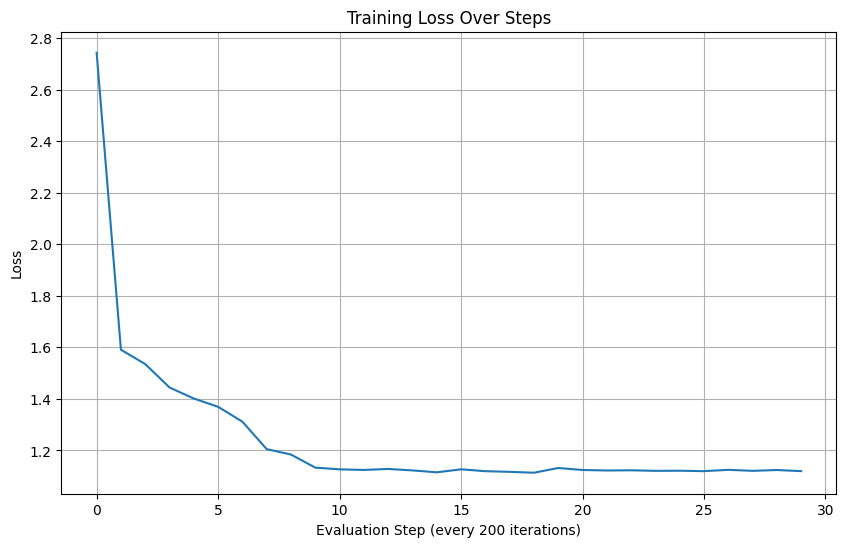

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(loss_history)
plt.title('Training Loss Over Steps')
plt.xlabel('Evaluation Step (every 200 iterations)')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

# Milestone 4 — Autoregressive Generation

## Goal

Generate text one token at a time.

The model should complete:

```text
12+35=
```

with:

```text
47
```

# Step 1 — Generation Function

In [17]:
@torch.no_grad()
def generate(model, start_text, max_new_tokens=10, temperature=1.0):

    model.eval()

    # Encode input
    idx = torch.tensor([encode(start_text)], dtype=torch.long).to(device)

    for _ in range(max_new_tokens):

        # Crop context window
        idx_cond = idx[:, -block_size:]

        # Forward pass
        logits, _ = model(idx_cond)

        # Take last token logits
        logits = logits[:, -1, :]

        # Apply temperature
        logits = logits / temperature

        # Convert to probabilities
        probs = F.softmax(logits, dim=-1)

        # Sample next token using torch.multinomial
        idx_next = torch.multinomial(probs, num_samples=1)

        # Append prediction to sequence
        idx = torch.cat((idx, idx_next), dim=1)

    return decode(idx[0].tolist())

# Step 2 — Test Generation

In [18]:
print(generate(model, '12+35='))
print(generate(model, '99+18='))
print(generate(model, '384+217='))

12+35=47
40+2=42
99+18=117
34+57=
384+217=58
75+27=1


# Final Evaluation Milestone

## Goal

Achieve:

- >=95% accuracy on unseen 2-digit problems
OR
- >=95% accuracy on unseen 3-digit problems

# Mathematical Evaluation

This evaluation checks REAL arithmetic correctness.

The model only passes if:

1. Output parses correctly
2. Prediction equals actual sum

# Student Task

Complete all TODO sections.

Then run the evaluation block below.

# Self-Grading Block

In [19]:
import re


def extract_answer(text):

    # Extract digits after '='
    match = re.search(r'=([0-9]+)', text)

    if match:
        return match.group(1)

    return None


@torch.no_grad()
def evaluate_model(model, num_tests=200, max_digits=2):

    model.eval()

    correct = 0

    examples = []

    for _ in range(num_tests):

        a = random.randint(0, 10**max_digits - 1)
        b = random.randint(0, 10**max_digits - 1)

        prompt = f'{a}+{b}='

        generated = generate(
            model,
            prompt,
            max_new_tokens=max_digits + 3,
            temperature=0.1
        )

        predicted = extract_answer(generated)

        expected = str(a + b)

        is_correct = predicted == expected

        if is_correct:
            correct += 1

        examples.append({
            'prompt': prompt,
            'prediction': predicted,
            'expected': expected,
            'correct': is_correct
        })

    accuracy = correct / num_tests

    return accuracy, examples

  # =====================================================
# SELF-GRADING CHECKLIST
# =====================================================

score = 0
max_score = 100

print('\n===============================')
print('AUTOGRADER RESULTS')
print('===============================\n')

# -----------------------------------------------------
# CHECK 1 — Tokenizer
# -----------------------------------------------------

try:
    encoded = encode('12+7=19')
    decoded = decode(encoded)

    if decoded == '12+7=19':
        print('[PASS] Tokenizer encode/decode works')
        score += 15
    else:
        print('[FAIL] Tokenizer mismatch')

except Exception as e:
    print('[FAIL] Tokenizer crashed:', e)


# -----------------------------------------------------
# CHECK 2 — Batch Generation
# -----------------------------------------------------

try:
    X, Y = get_batch()

    if X.shape == Y.shape:
        print('[PASS] Batch generation works')
        score += 15
    else:
        print('[FAIL] Batch shapes incorrect')

except Exception as e:
    print('[FAIL] Batch generation crashed:', e)


# -----------------------------------------------------
# CHECK 3 — Attention Layer
# -----------------------------------------------------

try:
    # Correctly instantiate Head with input_dim=64 to match the test 'x'
    test_head = Head(64, 16).to(device) # input_dim=64, head_size=16

    x = torch.randn(4, block_size, 64).to(device)

    out = test_head(x)

    if out.shape[0] == 4:
        print('[PASS] Attention head runs')
        score += 20
    else:
        print('[FAIL] Attention output incorrect')

except Exception as e:
    print('[FAIL] Attention layer crashed:', e)


# -----------------------------------------------------
# CHECK 4 — Model Forward Pass
# -----------------------------------------------------

try:
    xb, yb = get_batch()

    logits, loss = model(xb, yb)

    if logits.shape[0] == xb.shape[0]:
        print('[PASS] Model forward pass works')
        score += 20
    else:
        print('[FAIL] Model logits incorrect')

except Exception as e:
    print('[FAIL] Model forward pass crashed:', e)


# -----------------------------------------------------
# CHECK 5 — Arithmetic Accuracy
# -----------------------------------------------------

try:
    accuracy, examples = evaluate_model(
        model,
        num_tests=100,
        max_digits=2
    )

    print(f'\n2-digit accuracy: {accuracy:.2%}')

    if accuracy >= 0.95:
        print('[PASS] Achieved >=95% accuracy')
        score += 30
    else:
        print('[FAIL] Accuracy below 95%')

    print('\nExample predictions:\n')

    for ex in examples[:10]:
        print(ex)

except Exception as e:
    print('[FAIL] Evaluation crashed:', e)


# =====================================================
# FINAL SCORE
# =====================================================

print('\n===============================')
print(f'FINAL SCORE: {score}/{max_score}')
print('===============================\n')

if score == 100:
    print('Excellent work — your Tiny Transformer learned arithmetic.')
elif score >= 80:
    print('Good job — most Transformer components work correctly.')
else:
    print('Review the TODO sections and debug carefully.')



AUTOGRADER RESULTS

[PASS] Tokenizer encode/decode works
[PASS] Batch generation works
[PASS] Attention head runs
[PASS] Model forward pass works

2-digit accuracy: 92.00%
[FAIL] Accuracy below 95%

Example predictions:

{'prompt': '54+83=', 'prediction': '137', 'expected': '137', 'correct': True}
{'prompt': '35+79=', 'prediction': '114', 'expected': '114', 'correct': True}
{'prompt': '74+41=', 'prediction': '115', 'expected': '115', 'correct': True}
{'prompt': '23+90=', 'prediction': '113', 'expected': '113', 'correct': True}
{'prompt': '24+19=', 'prediction': '43', 'expected': '43', 'correct': True}
{'prompt': '40+25=', 'prediction': '65', 'expected': '65', 'correct': True}
{'prompt': '93+60=', 'prediction': '153', 'expected': '153', 'correct': True}
{'prompt': '60+82=', 'prediction': '142', 'expected': '142', 'correct': True}
{'prompt': '37+99=', 'prediction': '136', 'expected': '136', 'correct': True}
{'prompt': '23+20=', 'prediction': '43', 'expected': '43', 'correct': True}

FIN

# Stretch Goals

If you finish early:

1. Add dropout
2. Add learning-rate scheduling
3. Train on subtraction
4. Add multiplication
5. Compare greedy decoding vs sampling
6. Visualize attention maps
7. Train on 4-digit addition
8. Add teacher forcing experiments
9. Implement KV caching
10. Compare parameter counts vs accuracy

# Suggested Hyperparameters

These are known-good starter values:

```python
batch_size = 32
block_size = 32
n_embd = 64
n_head = 4
n_layer = 2
learning_rate = 1e-3
max_iters = 3000
```

# Submission Requirements

Submit:

1. Completed notebook
2. Final autograder score
3. Screenshot of generated examples
4. Short explanation:
   - What was hardest?
   - What debugging strategy worked best?
   - What surprised you about Transformers?

# Important Conceptual Questions

You should be able to explain:

1. Why is the causal mask necessary?
2. Why do we shift targets by one token?
3. Why do we add positional embeddings?
4. Why do residual connections help?
5. Why does the model eventually learn carrying operations?
6. Why is addition a sequence modeling problem?
7. What happens if the block size is too small?

# Recommended Debugging Strategy

1. First verify tokenizer correctness
2. Then verify batches
3. Then verify attention dimensions
4. Then verify loss decreases
5. Finally test arithmetic correctness

Do not attempt to debug the full model all at once.

# Expected Results

Typical training progression:

```text
step 0     loss ~2.5
step 500   loss ~1.2
step 1500  loss ~0.4
step 3000  loss ~0.1
```

Final 2-digit accuracy:

```text
95% - 100%
```

# Final Reflection

This assignment demonstrates a profound idea:

A Transformer trained only on next-character prediction can learn an algorithmic process like arithmetic.

No calculator rules were explicitly programmed.

The model discovers the structure of addition from examples.